In [17]:
import MoviDataset
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from torchvision import io
import torch
import numpy as np

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:

path='/home/nfs/inf6/data/datasets/MOVi/movi_c/'
video_dataset= MoviDataset.MoviDataset(path,split='validation') 
BATCH_SIZE = 32
video_loader = DataLoader(dataset=video_dataset, 
                          batch_size=BATCH_SIZE,
                          shuffle=False)

[INFO] - Data Loaded: Coordinates: 250, Masks: 250, RGB videos:  250, Flows:  250


### Images

In [7]:
path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/validation/rgb_00208_07.png'
rgb_image = io.read_image(path=path).to(torch.float32)
rgb_image.shape

torch.Size([3, 128, 128])

### Flow

In [ ]:

path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/validation/flow_00208_07.png'
flow = io.read_image(path=path).to(torch.float32)
flow.shape

torch.Size([3, 128, 128])

### Masks

In [8]:

path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/train/mask_00000.pt'
mask = torch.load(path, map_location="cpu")
mask['masks'].shape


torch.Size([24, 128, 128])

In [9]:
mask.keys()

dict_keys(['masks'])

In [11]:
print(mask['masks'].shape)
print(mask['masks'].unique())

torch.Size([24, 128, 128])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.uint8)


In [11]:
mask['masks'][9]

tensor([[0, 0, 2,  ..., 0, 0, 0],
        [0, 0, 2,  ..., 0, 0, 0],
        [0, 0, 2,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], dtype=torch.uint8)

### Coordinates

In [13]:
path = '/home/nfs/inf6/data/datasets/MOVi/movi_c/validation/coords_00236.pt'
coord = torch.load(path, map_location="cpu")
print("Keys in loaded coord dict:", coord.keys())
print("Shape of coord['com']:", coord['com'].shape)
print("Shape of coord['bbox']:", coord['bbox'].shape)

Keys in loaded coord dict: dict_keys(['com', 'bbox'])
Shape of coord['com']: torch.Size([24, 11, 2])
Shape of coord['bbox']: torch.Size([24, 11, 4])


### Data Visualization

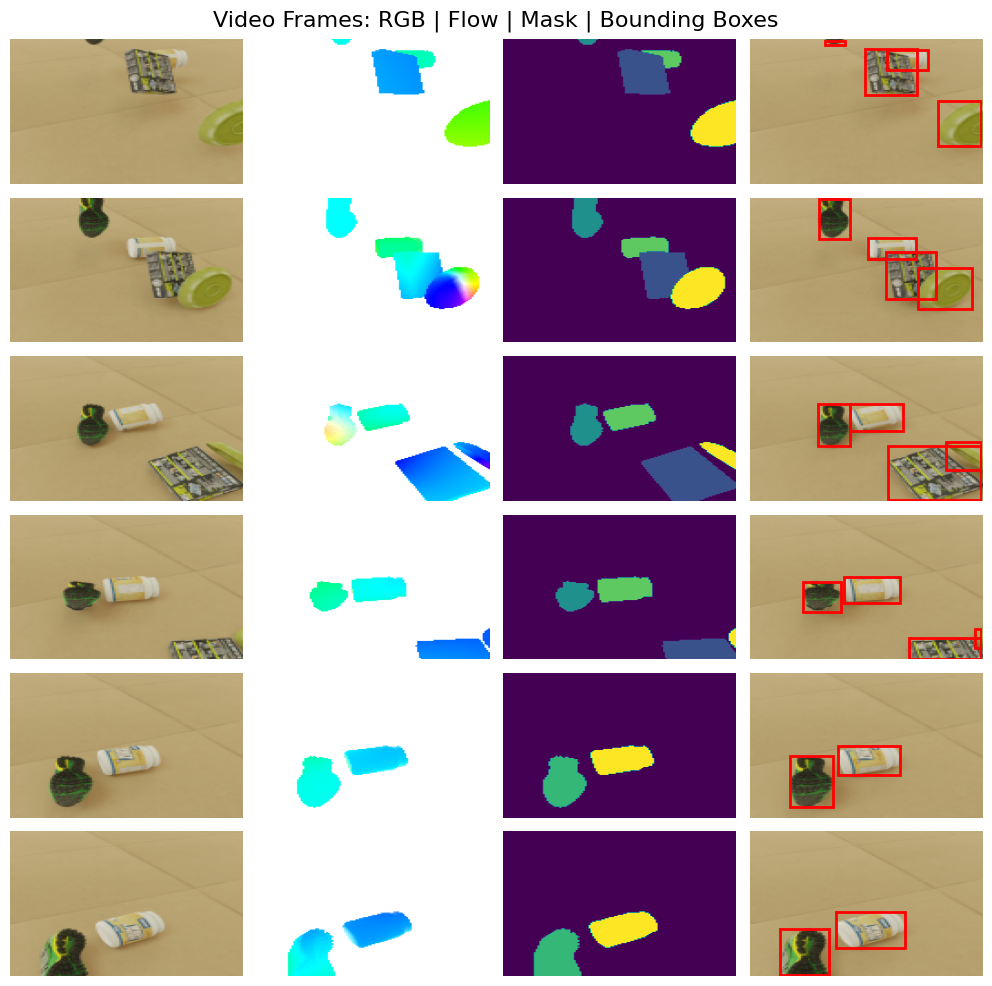

In [65]:
coords, masks, rgbs, flows = next(iter(video_loader))

idx = np.random.randint(0, BATCH_SIZE) #select a random video in the batch

video_frames_data = video_dataset.get_video_frame_labels(coords['com'][idx], 
                                                        coords['bbox'][idx], 
                                                        masks['masks'][idx], 
                                                        rgbs[idx], 
                                                        flows[idx])

# 24 frames x 4 columns (RGB, Flow, Mask, BBox)
fig, axes = plt.subplots(6, 4, figsize=(10, 10))
fig.suptitle('Video Frames: RGB | Flow | Mask | Bounding Boxes', fontsize=16)

i = 0

for frame_idx in range(1,len(video_frames_data),4):
    coord, bbox, mask, rgb, flow = video_frames_data[frame_idx]
    
    # RGB image
    axes[i, 0].imshow((rgb).clamp(0, 255).permute(1,2,0).byte().numpy())
    axes[i, 0].axis("off")
    # axes[i, 0].set_title(f"RGB Frame {frame_idx}")
    axes[i, 0].set_aspect('auto')
    
    # Flow image
    axes[i, 1].imshow((flow).clamp(0, 255).permute(1,2,0).byte().numpy())
    axes[i, 1].axis("off")
    # axes[i, 1].set_title(f"Flow Frame {frame_idx}")
    axes[i, 1].set_aspect('auto')
    
    
    # Mask image
    axes[i, 2].imshow((mask).clamp(0, 255).byte().numpy())
    axes[i, 2].axis("off")
    # axes[i, 2].set_title(f"Mask Frame {frame_idx}")
    axes[i, 2].set_aspect('auto')
    
    
    # Bounding boxes visualization
    axes[i, 3].imshow((rgb).clamp(0, 255).permute(1,2,0).byte().numpy())
    axes[i, 3].axis("off")
    # axes[i, 3].set_title(f"BBox Frame {frame_idx}")
    axes[i, 3].set_aspect('auto')
    

            # Draw bounding boxes
    for obj_idx in range(bbox.shape[0]):
        x1, y1, x2, y2 = bbox[obj_idx].tolist()
        width, height = x2 - x1, y2 - y1
        rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='red', facecolor='none')
        axes[i, 3].add_patch(rect)

    i += 1
    
# Remove whitespace between columns and rows
plt.subplots_adjust(wspace=25, hspace=25)
plt.tight_layout(pad=1)
plt.show()


In [6]:
from transformers import VivitModel, VivitConfig
model = VivitModel.from_pretrained("google/vivit-b-16x2-kinetics400", attn_implementation="sdpa", dtype=torch.float16)


Some weights of VivitModel were not initialized from the model checkpoint at google/vivit-b-16x2-kinetics400 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
# Initializing a ViViT google/vivit-b-16x2-kinetics400 style configuration
configuration = VivitConfig()

# Initializing a model (with random weights) from the google/vivit-b-16x2-kinetics400 style configuration
model = VivitModel(configuration)

# Accessing the model configuration
configuration = model.config

In [8]:
model

VivitModel(
  (embeddings): VivitEmbeddings(
    (patch_embeddings): VivitTubeletEmbeddings(
      (projection): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): VivitEncoder(
    (layer): ModuleList(
      (0-11): 12 x VivitLayer(
        (attention): VivitAttention(
          (attention): VivitSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): VivitSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): VivitIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (intermediate_

In [9]:
configuration

VivitConfig {
  "attention_probs_dropout_prob": 0.0,
  "hidden_act": "gelu_fast",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-06,
  "model_type": "vivit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_frames": 32,
  "num_hidden_layers": 12,
  "qkv_bias": true,
  "transformers_version": "4.56.0",
  "tubelet_size": [
    2,
    16,
    16
  ]
}